#Data Analysis using Datasets after Data Quality Assessment

In [ ]:
import pandas as pd

In [88]:
# orders_qu.csv
url = "https://drive.google.com/file/d/1sW32ox48H51IOJOm_y6rJxpExpVNyJe2/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders = pd.read_csv(path)

orders_df = orders.copy()

In [ ]:
# orderlines_qu.csv
url = "https://drive.google.com/file/d/18EEFxlaM8IdGX1XIqLMM1qqsYOnVCYQb/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines = pd.read_csv(path)

orderlines_df = orderlines.copy()

In [ ]:
# products_qu.csv
url = "https://drive.google.com/file/d/1KAU235y8NmRW2TfdBN9jUbJwDfceUnb3/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products = pd.read_csv(path)

products_df = products.copy()

In [ ]:
# brands_qu.csv
url = "https://drive.google.com/file/d/11u-yJ9JLXMNEi6glyjQrY2j0U6Xl8KN3/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
brands = pd.read_csv(path)

brands_df = brands.copy()

# Set display format

In [ ]:
# display numbers with only two decimal places
pd.set_option("display.float_format", lambda x: "%.2f" % x)
# display up to 1000 rows at once
pd.set_option("display.max_rows", 1000)
#display column width to dsiplay all row information
pd.set_option('display.max.colwidth',None)
#maximize the display width
pd.set_option('display.width',None)

## Checking the time period of the dataset

In [ ]:
# extracting the date columns from orders_df and orderlines_df
orderlines_df['date'] = pd.to_datetime(orderlines_df['date'])
orders_df['created_date'] = pd.to_datetime(orders_df['created_date'])

In [ ]:
# calculating the time period from oderlines_df
time_period = orderlines_df['date'].max() - orderlines_df['date'].min()
days        = time_period.components.days
hours       = time_period.components.hours
minutes     = time_period.components.minutes
seconds     = time_period.components.seconds
print(f'The time period of the dataset is {days} days, {hours} hours, {minutes} minutes and {seconds} seconds.')

The time period of the dataset is 437 days, 10 hours, 11 minutes and 57 seconds.


In [ ]:
#checking whether the obtained result matched the result if time_period was calculated from orders_df
time_period == (orders_df['created_date'].max() - orders_df['created_date'].min())

False

In [ ]:
# checking the order that has the latest time in orderlines_df
orderlines_df.loc[orderlines_df['date'] == orderlines_df['date'].max(), :]

,order_id,product_quantity,sku,unit_price,date,unit_total
54124,527112,1,APP0698,9.99,2018-03-14 11:58:13,9.99


In [ ]:
# checking the order that has the latest time in orders_df
orders_df.loc[orders_df['created_date'] == orders_df['created_date'].max(), :]

,order_id,created_date,total_paid,state
41483,527112,2018-03-14 12:03:52,14.98,Completed


- The orders_df timestamps one entry of the earliest time/ first product when the order was initialized. Thus, orderlines_df makes more sense to use as it specifies the time for each product in an order

## Calculating the overall revenue

In [ ]:
# summing the unit_total from orderlines_df since it excludes the extra costs such as shipping (in the orders_df table)
overall_revenue = orderlines_df['unit_total'].sum()
print(f'The overall revenue for sold orders is {overall_revenue:.2f} EUROS')

The overall revenue for sold orders is 7888086.33 EUROS


In [ ]:
# confirming that the revenue is less than the revenue from the orders_df table
revenue = orders_df['total_paid'].sum()
overall_revenue < revenue

np.True_

- The overall revenue is calculated using the orderlines_df dataset since orders_df carries shipping costs/ gift wrapping costs etc thus not exclusively displaying ENIAC's revenue

## Looking for seasonal patterns

<Axes: title={'center': 'Sales across the Dataset'}, xlabel='Dates', ylabel='Number of Orders'>

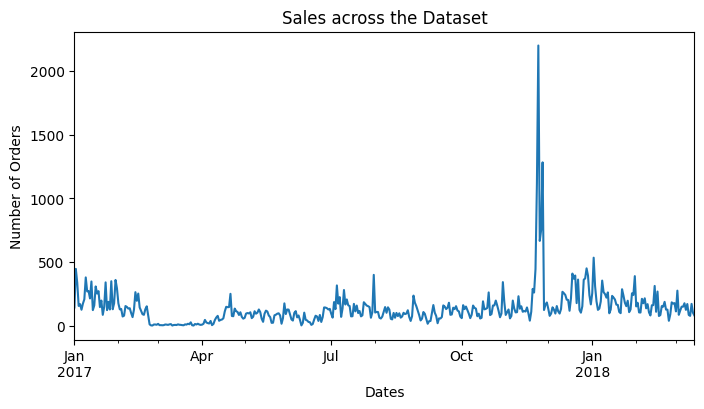

In [ ]:
# checking the sales across the whole dataset to get an idea
orderlines_df.resample('D', on='date')['product_quantity'].sum().plot(title=('Sales across the Dataset'),figsize=(8,4),xlabel=('Dates'),ylabel='Number of Orders')

<Axes: xlabel='Months', ylabel='Sold Products'>

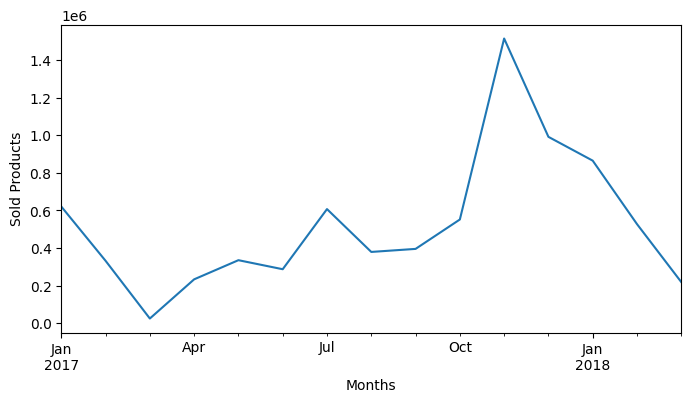

In [ ]:
# narrowing daily individual sales down to one month to get a better insight
orderlines_df.resample(
    'ME',on='date')['unit_total'].sum().plot(xlabel='Months', ylabel='Sold Products',figsize=(8,4)
)

- My take is it is not enough data to compare seasonality but we can take a look at days of the week (may be more sales over the weekend) and also check the peak (if it correlates to black Friday season)

-  I tried looking at shopping on each week day but don't think it informs much, other than that may be most people shop in the middle of the week rather than weekends

- this is why I just commented it out

In [ ]:
# orderlines_df['day_of_week'] = orderlines_df['date'].dt.day_name()
# orderlines_df.groupby('day_of_week')['product_quantity'].sum().plot(  kind='bar', figsize=(12,6), title='Sales by Day of Week', xlabel='Day', ylabel='Total Units Sold')

## Black Week 2017 (20 to 27 Nov, 2017)

### May be it makes more sense to zoom in on that peak

In [ ]:
# keep the Black Friday data only
mask = orderlines_df['date'].between('2017-11-20','2017-11-28')
black_friday_sales = orderlines_df.loc[mask,:]

<Axes: title={'center': 'Sales during Black Friday Week'}, xlabel='Dates of the Week', ylabel='Number of Orders'>

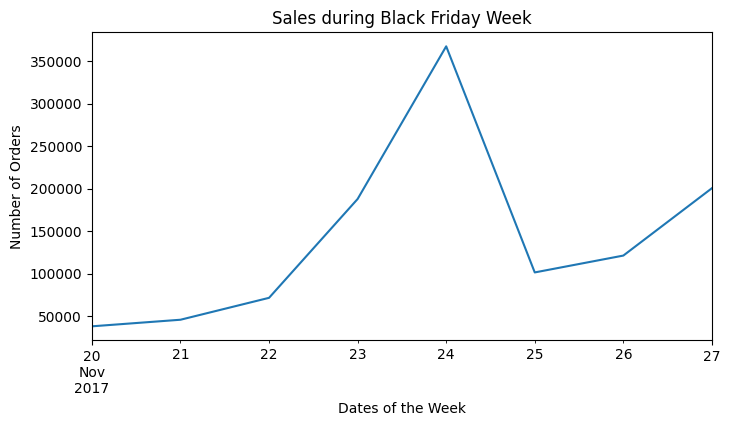

In [ ]:
# having a look at the Black Friday revenue generated
black_friday_sales.resample('D', on='date')['unit_total'].sum().plot(title=('Sales during Black Friday Week'),figsize=(8,4),xlabel=('Dates of the Week'),ylabel='Number of Orders')

- Black Friday recorded the most sales. 2017-11-24 has over 2000 sales, as a result November also ends with the highest sales

## Products sold the most

In [ ]:
# sorting the products by the sum of products sold and taking the largest 10
most_sold = orderlines_df.groupby('sku',as_index=False)['product_quantity'].sum().sort_values('product_quantity',ascending=False).head(10)
# merging with the products_df table to get the product names
most_sold_name = most_sold.merge(products_df,on='sku',how='inner')
most_sold_name.drop(['price', 'type'],axis=1)

,sku,product_quantity,name,desc
0,APP1190,957,IPhone AppleCare Protection Plan,Apple Care extended warranty iPhone.
1,APP0698,821,Apple Lightning Cable Connector to USB 1m White (OEM),Apple Lightning USB Cable 1 meter to charge and sync iPhone iPad and iPod
2,APP1922,540,AirPods Apple Bluetooth Headset for iPhone iPad iPod and Apple Watch,Apple AirPods wireless headsets and cargo transport box
3,APP0927,491,EarPods Apple Headphones with Remote and Mic (OEM),EarPods headphones Apple iPhone iPad and iPod with microphone and remote control
4,WDT0183,478,"Red 4TB WD 35 ""Mac PC hard drive and NAS",Western Digital hard drive designed for NAS 4TB (WD40EFRX).
5,CRU0051,339,Crucial MX300 525GB SSD Disk,SSD 525GB SATA Hard Disk 3.0 (6Gb / s) for Mac and PC
6,SAM0074,337,Samsung 850 EVO SSD Disk 500GB,SSD hard drive Mac and PC 25 inch 500GB SATA III with 3D V-NAND.
7,APP2446,270,Apple iPhone 6 32GB Space Gray,New iPhone 6 32GB Space Gray
8,CRU0050,260,Crucial MX300 275GB SSD Disk,SSD 275GB SATA Hard Disk 3.0 (6Gb / s) for Mac and PC
9,NTE0013,259,"AdaptaDrive NewerTech adapter 2.5 ""to 3.5"" SATA",Adapter HDD / SSD 2.5 SATA 3.5 compatible with Mac Pro.


## Products generating the most revenue

In [ ]:
# sorting the top 10 products generating the highest revenue(unit_total)
most_revenue = orderlines_df.groupby('sku',as_index=False)['unit_total'].sum().sort_values('unit_total',ascending=False).head(10)
# merging with the products_df table to get the product names
most_revenue_name = most_revenue.merge(products_df,on='sku',how='inner')
most_revenue_name.drop(['price', 'type'],axis=1)

,sku,unit_total,name,desc
0,LGE0044,136515.81,"LG 27UD88-W Monitor 27 ""UHD 4K USB 3.0 USB-C",99% Professional Monitor sRGB color calibrator cable USB-C connection for Mac and PC
1,APP2446,104560.64,Apple iPhone 6 32GB Space Gray,New iPhone 6 32GB Space Gray
2,APP1922,86960.26,AirPods Apple Bluetooth Headset for iPhone iPad iPod and Apple Watch,Apple AirPods wireless headsets and cargo transport box
3,APP2477,85301.93,Apple iPhone 64GB Space Gray 8,Apple iPhone 64GB 8 Color Space Gray
4,APP1970,81124.76,Apple iPhone 32GB Space Gray,New iPhone SE with 4-inch screen 32 free GB.
5,APP2072,74964.06,"Apple MacBook Air 13 ""Core i5 18GHz | 8GB RAM | 128GB SSD",laptop MacBook Air 13 inch i5 18GHz 8GB RAM and 128GB SSD
6,APP2485,70721.79,Apple iPhone 8 Plus 64GB Gold,Apple iPhone 8 Plus 64GB Gold color
7,WDT0183,65848.36,"Red 4TB WD 35 ""Mac PC hard drive and NAS",Western Digital hard drive designed for NAS 4TB (WD40EFRX).
8,APP2483,60090.08,Apple iPhone 8 Plus 64GB Space Gray,Apple iPhone 8 Plus 64GB Space Gray
9,APP2479,52981.19,Apple iPhone 64GB Gold 8,Apple iPhone 64GB 8 in Gold


#Time to look into Discounts

## Adding a discount column using unit price and price makes the most sense

In [89]:
# create new table by erging products_df with orderlines_df to get all prices in one table = simplifies anaylsis
discounts_df = orderlines_df.merge(products_df,on='sku',how='left')
# create a new column with values of the discount and discount rate
discounts_df['discount'] = discounts_df['price'] - discounts_df['unit_price']
discounts_df['discount_rate'] = discounts_df['discount']/ discounts_df['price'] *100

In [90]:
# exploring the maximum and minimum discount rates
discounts_df['discount_rate'].max(), discounts_df['discount_rate'].min()

(97.14081486776269, -212.26533166458074)

In [91]:
# merging with brands_df to get the long form names of the brands
discounts_df['short'] = discounts_df['sku'].str[:3]
discounts_df = discounts_df.merge(brands_df,on='short',how='left')

## Relation between discount and revenue

- I tried to look at a relation between revenue(sum) and discount(mean)
- Using daily data misinforms the trend (in my opinion)
- I then chose to use months and quarters

<Axes: title={'center': 'discount rate and revenue are not directly propotional to each other\n therefore suggesting other influencing factors'}, xlabel='date'>

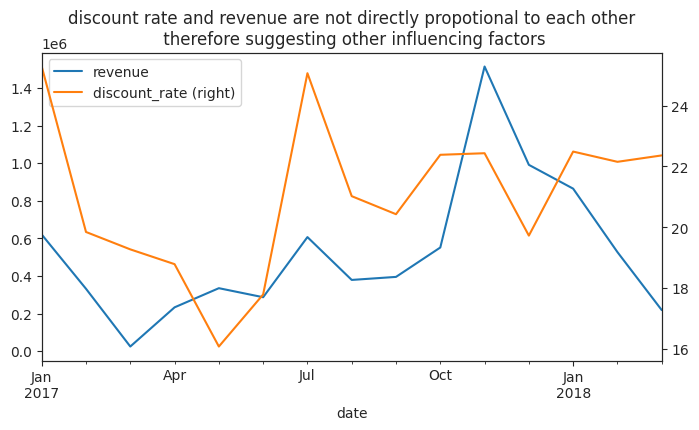

In [92]:
# resample into month end to plot both revenue and discount rate
months_new = discounts_df.resample('ME', on='date').agg(discount_rate=('discount_rate', 'mean'), revenue=('unit_total', 'sum')).reset_index()
months_new.plot(x='date',y=['revenue','discount_rate'],secondary_y='discount_rate',figsize=(8,4),title='discount rate and revenue are not directly propotional to each other\n therefore suggesting other influencing factors')

In [93]:
# resampling into quarters
mean_discount = discounts_df.resample('QE', on='date').agg(
    discount_rate=('discount_rate', 'mean'),
    revenue=('unit_total', 'sum')
).reset_index()

<Axes: title={'center': 'Comparison between Revenue & Discount Rate'}, xlabel='date'>

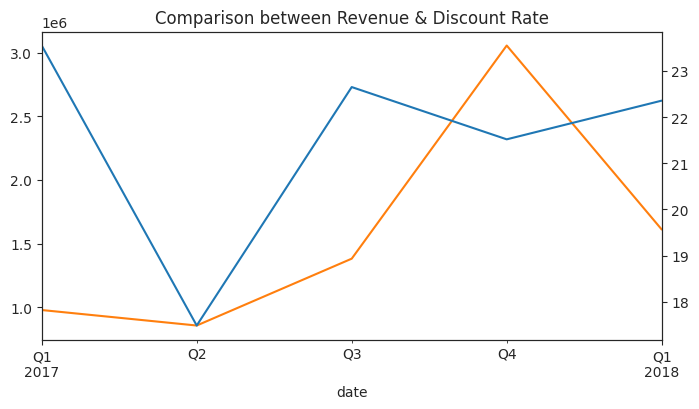

In [95]:
mean_discount.plot(x='date',y=['discount_rate','revenue'],secondary_y='discount_rate',figsize=(8,4),title='Comparison between Revenue & Discount Rate',legend=False)

- as an example during black friday, discounts were not at their maximum but revenue was high i.e. discount is not the only cause for revenue generation

###Let us try to use the pandas correlation method for discount and revenue

In [96]:
# using the Pearson correlation method
discounts_df[['discount_rate', 'unit_total']].corr(method='pearson',min_periods=30)

,discount_rate,unit_total
discount_rate,1.00,-0.30
unit_total,-0.30,1.00


- It appears discount is not the main driver for sales. While there is correlation betwee the two it appears there are other factors driving sale more than discounts

##May be we should compare discounts with number of orders

<Axes: title={'center': 'Comparison between Number of Orders & Revenue'}, xlabel='date'>

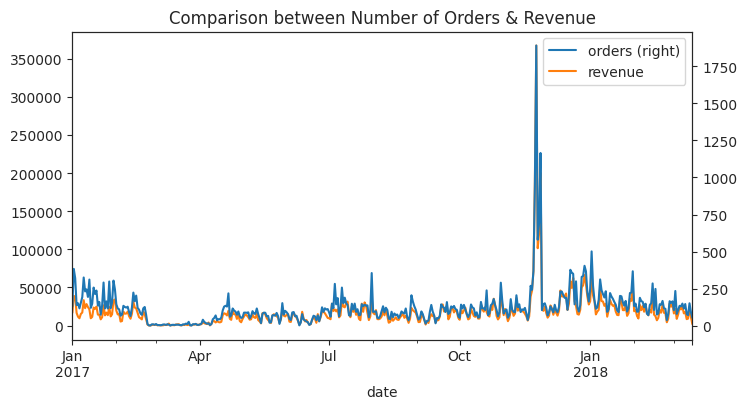

In [97]:
# resampling per day and comparing revenue to number of orders
discounts_df.resample('D',on='date').agg(revenue=('unit_total', 'sum'),
    orders=('order_id', 'count')).reset_index().plot(x='date',y=['orders','revenue'],secondary_y='orders',figsize=(8,4),title='Comparison between Number of Orders & Revenue')

In [ ]:
# calculating the correlation factor for the two variables
daily_values = discounts_df.resample('D', on='date').agg(
    revenue=('unit_total', 'sum'),
    orders=('order_id', 'count')
).reset_index()

daily_values[['revenue', 'orders']].corr(method='pearson')

,revenue,orders
revenue,1.00,0.97
orders,0.97,1.00


- Unlike discount, the revenue is proportional to the number of orders placed

###How many times has a product been discounted or how many products are being discounted

In [102]:
#group by product and take the max discount for it (at any point in time) to see which product has had the highest discount
max_discount_per_sku = discounts_df.groupby('sku',as_index=False)['discount'].max().sort_values(by='discount',ascending=False)
max_discount_sku = max_discount_per_sku.merge(products_df,how='inner',on='sku')
max_discount_sku = max_discount_sku.rename(columns={'discount': 'max_discount'})
max_discount_sku.head()

,sku,max_discount,name,desc,price,type,category
0,PAC2067,1320.00,"Second hand - Apple iMac 24 ""Core 2 Duo 28 GHz | 4GB RAM | 500GB HDD",Computer Refurbished iMac 24 inch Core 2 Duo 28GHz | 4GB RAM | 500GB HDD,1799.00,1282,
1,PAC2071,1310.00,"Second hand - Apple iMac 24 ""Core 2 Duo 28 GHz | 4GB RAM | 500GB HDD",Computer Refurbished iMac 24 inch Core 2 Duo 28 GHz | 4GB RAM | 500GB HDD,1799.00,1282,
2,PAC2065,1300.00,"Second hand - Apple iMac 24 ""Core 2 Duo 28 GHz | 4GB RAM | 500GB HDD",Computer Refurbished iMac 24 inch Core 2 Duo 28 GHz | 4GB RAM | 500GB HDD,1799.00,1282,
3,PAC2281,1243.41,"Second hand - Apple iMac 20 ""Core 2 Duo 226GHz | 2GB RAM | 160GB HDD",Refurbished iMac 20 inch Core 2 Duo | 2GB RAM | 160GB HDD,1499.00,"5,43E+15",
4,PAC2062,1163.41,"Second hand - Apple iMac 20 ""Core 2 Duo 266GHz | 4GB RAM | 250GB HDD",IMac used 20 inch Core 2 Duo 266GHz | 4GB RAM | 250GB HDD,1499.00,51882158,


- Pack products normally have the highest discounts

In [99]:
# group by product and count the number of times it appears (this will show which product has been discounted the most times in the dataset)
discounted = discounts_df.loc[discounts_df['discount']!= 0,:]
most_discounted_counts = discounted.groupby('sku',as_index=False)['discount'].count().sort_values(by='discount',ascending=False)

In [100]:
most_discounted_detailed = most_discounted_counts.merge(products_df,on='sku',how='inner')
most_discounted_detailed = most_discounted_detailed.rename(columns={'discount': 'number_of_times_discounted'})
most_discounted_detailed.head(5)

,sku,number_of_times_discounted,name,desc,price,type,category
0,APP1190,862,IPhone AppleCare Protection Plan,Apple Care extended warranty iPhone.,70.00,1231,
1,APP0698,479,Apple Lightning Cable Connector to USB 1m White (OEM),Apple Lightning USB Cable 1 meter to charge and sync iPhone iPad and iPod,25.00,1230,
2,APP1922,451,AirPods Apple Bluetooth Headset for iPhone iPad iPod and Apple Watch,Apple AirPods wireless headsets and cargo transport box,179.00,5384,
3,APP0927,379,EarPods Apple Headphones with Remote and Mic (OEM),EarPods headphones Apple iPhone iPad and iPod with microphone and remote control,35.00,5384,
4,SAM0074,306,Samsung 850 EVO SSD Disk 500GB,SSD hard drive Mac and PC 25 inch 500GB SATA III with 3D V-NAND.,179.99,12215397,


## Compare the number of discounted sales versus those that are not

In [ ]:
discounted_order = len(discounts_df.loc[discounts_df['discount'] > 0,:])

In [ ]:
nondiscounted_order = len(discounts_df.loc[discounts_df['discount'] == 0,:])

In [ ]:
# calculate the negatively discounted orders
percent_negative_discounts = len(discounts_df.loc[discounts_df['discount'] < 0,:])/len(discounts_df) *100
print(f'The negatively discounted orders account to {percent_negative_discounts:.2f} of all orders')

The negatively discounted orders account to 2.96 of all orders


In [ ]:
# calculate the percent of discounted orders (positive)
percent_positive_discount = len(discounts_df.loc[discounts_df['discount'] > 0,:])/len(discounts_df) *100
print(f'The number of positively  discounted orders is {percent_positive_discount:.2f}')

The number of positively  discounted orders is 92.83


## We can later try to show the unique products that have never been dicsounted

In [101]:
mask_no_discount = discounts_df['discount'] == 0
mask_discount = discounts_df['discount'] > 0
not_discounted = discounts_df.loc[~mask_discount & mask_no_discount,:]
all = len(discounts_df['sku'].unique())
no = len(not_discounted['sku'].unique())
per = no/all * 100
print(f'The number of products that have never been discounted is {no} out of {all} products sold which is {per:.2f}%.')

The number of products that have never been discounted is 481 out of 5184 products sold which is 9.28%.


## The dilemna remains on orders were discount is -

In [ ]:
# explore the products whose discount is negative
mask_negative = discounts_df['discount'] < 0
discounts_df.loc[mask_negative,:].sort_values(by='discount',ascending=True).head(10)

,order_id,product_quantity,sku,unit_price,date,unit_total,brand,name,desc,price,discount,discount_rate
29971,428397,1,PAC1388,848.32,2017-11-19 13:23:40,848.32,PAC,Pack QNAP TS-251 + | 2GB RAM | WD 16TB Network,Nas QNAP TS-251 + 2GB RAM memory + 16TB (2x8TB) Hard Red WD Mac and PC.,673.70,-174.62,-25.92
2149,306995,1,LAC0179,889.99,2017-01-11 01:05:52,889.99,LAC,12TB LaCie 2big Thunderbolt 2,Dual RAID disk box 12TB Thunderbolt 2 for Mac and PC,719.00,-170.99,-23.78
1265,304102,1,LAC0179,889.99,2017-01-07 10:13:51,889.99,LAC,12TB LaCie 2big Thunderbolt 2,Dual RAID disk box 12TB Thunderbolt 2 for Mac and PC,719.00,-170.99,-23.78
20695,390915,1,APP1647,770.33,2017-08-20 16:15:13,770.33,APP,Apple iPhone 32GB Rose Gold 7,New Apple iPhone 32GB Rose Gold 7 Free,639.00,-131.33,-20.55
22135,396512,1,APP1664,660.33,2017-09-04 21:04:08,660.33,APP,Apple iPhone 6s 32GB Gold,New 32GB iPhone 6S Libre.,529.00,-131.33,-24.83
21715,394467,1,APP1662,660.33,2017-08-30 11:51:17,660.33,APP,Apple iPhone 6s 32GB Space Gray,New 32GB iPhone 6S Libre.,529.00,-131.33,-24.83
22100,396371,1,APP1651,880.33,2017-09-04 14:19:11,880.33,APP,Apple iPhone 7 128GB Gold Rosa,New Apple iPhone 7 128GB Rose Gold free,749.00,-131.33,-17.53
19390,385899,1,APP1665,660.33,2017-08-03 16:26:46,660.33,APP,32GB Apple iPhone 6s Rose Gold,New 32GB iPhone 6S Libre.,529.00,-131.33,-24.83
21099,392487,1,APP1652,880.33,2017-08-24 19:52:21,880.33,APP,Apple iPhone 7 128GB Black Bright,New Apple iPhone 7 128GB Black Free Bright,749.00,-131.33,-17.53
21865,395191,1,APP1664,660.33,2017-08-31 20:25:24,660.33,APP,Apple iPhone 6s 32GB Gold,New 32GB iPhone 6S Libre.,529.00,-131.33,-24.83


In [ ]:
# explore one product
discounts_df.loc[discounts_df['sku'] == 'APP1647',:].sort_values(by='unit_price',ascending=False)

,order_id,product_quantity,sku,unit_price,date,unit_total,brand,name,desc,price,discount,discount_rate
20695,390915,1,APP1647,770.33,2017-08-20 16:15:13,770.33,APP,Apple iPhone 32GB Rose Gold 7,New Apple iPhone 32GB Rose Gold 7 Free,639.00,-131.33,-20.55
134,300152,1,APP1647,769.00,2017-01-02 00:25:21,769.00,APP,Apple iPhone 32GB Rose Gold 7,New Apple iPhone 32GB Rose Gold 7 Free,639.00,-130.00,-20.34
2343,307560,1,APP1647,769.00,2017-01-11 20:39:47,769.00,APP,Apple iPhone 32GB Rose Gold 7,New Apple iPhone 32GB Rose Gold 7 Free,639.00,-130.00,-20.34
931,302666,1,APP1647,769.00,2017-01-04 18:39:41,769.00,APP,Apple iPhone 32GB Rose Gold 7,New Apple iPhone 32GB Rose Gold 7 Free,639.00,-130.00,-20.34
1315,304264,1,APP1647,635.54,2017-01-07 15:03:05,635.54,APP,Apple iPhone 32GB Rose Gold 7,New Apple iPhone 32GB Rose Gold 7 Free,639.00,3.46,0.54
22911,401045,1,APP1647,627.33,2017-09-17 20:07:55,627.33,APP,Apple iPhone 32GB Rose Gold 7,New Apple iPhone 32GB Rose Gold 7 Free,639.00,11.67,1.83
23175,401968,1,APP1647,627.33,2017-09-19 19:23:11,627.33,APP,Apple iPhone 32GB Rose Gold 7,New Apple iPhone 32GB Rose Gold 7 Free,639.00,11.67,1.83
24074,405303,1,APP1647,627.33,2017-09-27 15:41:36,627.33,APP,Apple iPhone 32GB Rose Gold 7,New Apple iPhone 32GB Rose Gold 7 Free,639.00,11.67,1.83
24210,405869,1,APP1647,627.33,2017-09-28 19:29:45,627.33,APP,Apple iPhone 32GB Rose Gold 7,New Apple iPhone 32GB Rose Gold 7 Free,639.00,11.67,1.83
25310,410628,1,APP1647,627.33,2017-10-09 20:23:36,627.33,APP,Apple iPhone 32GB Rose Gold 7,New Apple iPhone 32GB Rose Gold 7 Free,639.00,11.67,1.83


## Assumption:
- the price of the item decreased overtime, therefore the items sold at the initial times seem to appear as though they were sold at a negative discount (iin comparison to the base price) meanwhile the price was discounted at the time of sale but not below the base price at time of data extraction

- consider that this product was a 2016 release (apple products tend to drop in price upon release of the next)

### Let us try another product

In [ ]:
# explore another product to see if the assumpion is justified
discounts_df.loc[discounts_df['sku'] == 'PAC1388',:].sort_values(by='unit_price',ascending=False)

,order_id,product_quantity,sku,unit_price,date,unit_total,name,desc,price,discount,discount_rate,short,long_x,long_y,long
29971,428397,1,PAC1388,848.32,2017-11-19 13:23:40,848.32,Pack QNAP TS-251 + | 2GB RAM | WD 16TB Network,Nas QNAP TS-251 + 2GB RAM memory + 16TB (2x8TB) Hard Red WD Mac and PC.,673.70,-174.62,-25.92,PAC,Pack,Pack,Pack


- Same observation: Negative discounts are due to drop in price

## Creating categories for the products

In [ ]:
#creating a new column in the products_df table
products_df['category'] = ''

In [ ]:
# let us figure out the number of types
products_df['type'].value_counts()

,count
type,
11865403,1061
12175397,941
1298,820
11935397,565
11905404,464
1282,373
12635403,367
13835403,269
"5,74E+15",247


In [ ]:
#Apple MacBook Retina 12 "Core
#mask = products['name'].str.contains(r'Apple macbook Retina \d*\s"Core',case=False)
#len(products_df.loc[mask,:])

In [ ]:
# starting to create categories
products_df.loc[products_df['type']=='11865403','category'] += 'phone case'
products_df.loc[products_df['type']=='12175397','category'] += 'server'
products_df.loc[products_df['type'].isin(['5,74E+15','5,39E+11']),'category'] += 'laptop'
products_df.loc[products_df['type']=='1,44E+11','category'] += 'service' #repair

In [ ]:
# keep track of how many products are not assigned yet
products_df['category'].value_counts()

,count
category,
,7702
phone case,1061
server,941
laptop,294
service,159


In [ ]:
orders_df.to_csv("../Data/Cleaned/orders_cl.csv", index=False)

orderlines_df.to_csv("../Data/Cleaned/orderlines_cl.csv", index=False)

Data Exports

In [105]:
from google.colab import drive
drive.mount('/content/drive')

import os

save_path = "/content/drive/MyDrive/Data/Datasets/Present"
os.makedirs(save_path, exist_ok=True)

discounts_df.to_csv(f"{save_path}/discounts_df.csv", index=False)

Mounted at /content/drive
